# **Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from skimage import io, color, img_as_float
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from torch.utils.data import DataLoader
from google.colab import drive
drive.mount('/content/drive')

# GAN
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, datasets

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Mounted at /content/drive


In [2]:
import os

In [3]:
folder_path = '/content/drive/MyDrive/Colab Notebooks/DSGP Implementation'

# **Loading The Data**

In [4]:
drive.mount('/content/drive')
train_dir = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/train/class A"
val_dir = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/test/class A"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Preprocessing**

# **Fast-Fourier Transforms**

In [5]:
# Applying FFT
images = list(io.imread_collection(os.path.join(train_dir, "*.png")))
print(f"Loaded {len(images)} images")

Loaded 10 images


In [6]:
import os
import numpy as np
from skimage import io, color, img_as_float, img_as_ubyte
import matplotlib.pyplot as plt

output_dir = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft"  # folder to save compressed images
keep_fraction = 0.1

# Output directory
os.makedirs(output_dir, exist_ok=True)
images = io.imread_collection(os.path.join(train_dir, "*.png"))

Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_0.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_1.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_2.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_3.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_4.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_5.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_6.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compressed_7.png
Processed and saved: /content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft/compresse

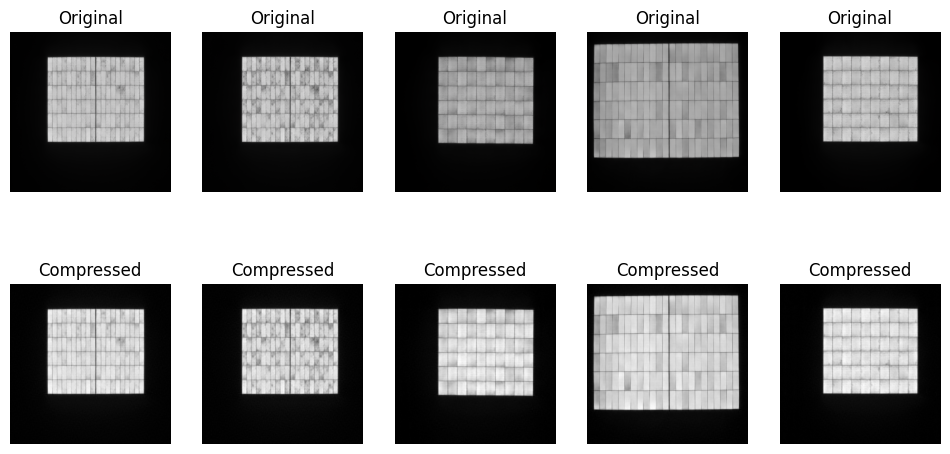

In [7]:
for idx, img in enumerate(images):
    # Convert to grayscale if RGB
    if len(img.shape) == 3:   # would have (H, W, 3)
        img = color.rgb2gray(img)

    # convert to [0,1]
    img = img_as_float(img)

    # FFT
    fft_image = np.fft.fft2(img)
    fft_shifted = np.fft.fftshift(fft_image)

    # Keep only top fraction of coefficients
    magnitude = np.abs(fft_shifted)
    threshold = np.percentile(magnitude, (1 - keep_fraction) * 100)
    fft_shifted_compressed = fft_shifted * (magnitude >= threshold)

    # Inverse FFT to reconstruct
    fft_ishift = np.fft.ifftshift(fft_shifted_compressed)
    img_reconstructed = np.fft.ifft2(fft_ishift)
    img_reconstructed = np.abs(img_reconstructed)

    # Convert back to uint8 for saving
    img_reconstructed_uint8 = img_as_ubyte(img_reconstructed)

    # Save compressed image
    output_path = os.path.join(output_dir, f"compressed_{idx}.png")
    io.imsave(output_path, img_reconstructed_uint8)

    print(f"Processed and saved: {output_path}")


plt.figure(figsize=(12, 6))
for i in range(min(5, len(images))):
    plt.subplot(2, 5, i+1)
    plt.imshow(img_as_float(images[i]), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(2, 5, i+6)
    compressed_img = io.imread(os.path.join(output_dir, f"compressed_{i}.png"))
    plt.imshow(compressed_img, cmap='gray')
    plt.title("Compressed")
    plt.axis('off')
plt.show()

# **Data Augmentation**

In [8]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft"

transform = transforms.Compose([
    transforms.Grayscale(1),
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [9]:
dataset = datasets.ImageFolder(root="/content/drive/MyDrive/Colab Notebooks/DSGP Implementation/compressed_fft", transform=transform)

In [10]:
# Creating a data loader
loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [11]:
z_dim = 100

In [12]:
# Generator
class Generator(nn.Module):
  def __init__(self, z_dim=100):
    super().__init__()
    self.net = nn.Sequential(
        nn.ConvTranspose2d(z_dim, 256, 4, 1, 0), nn.BatchNorm2d(256), nn.ReLU(True),
        nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.ReLU(True),
        nn.ConvTranspose2d(128, 64, 4, 2, 1),  nn.BatchNorm2d(64),  nn.ReLU(True),
        nn.ConvTranspose2d(64, 1, 4, 2, 1), nn.Tanh()
    )

  def forward(self, x):
    return self.net(x)

In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,64,4,2,1), nn.LeakyReLU(0.2, True),
            nn.Conv2d(64,128,4,2,1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2, True),
            nn.Conv2d(128,256,4,2,1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2, True),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),  # -> (batch_size,256,1,1)
            nn.Conv2d(256,1,1,1,0),   # -> (batch_size,1,1,1)
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.view(-1,1)  # shape = (batch_size,1)


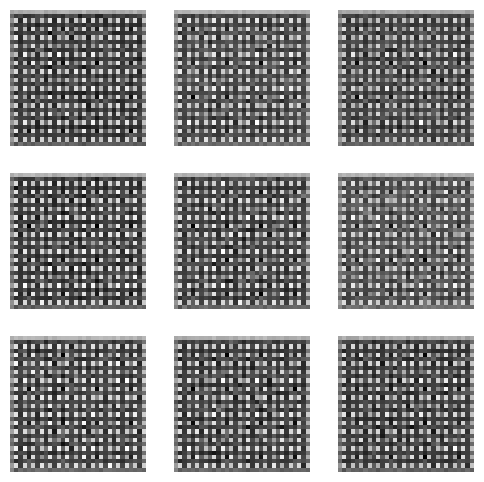

In [14]:
G = Generator(z_dim).to(device)
D = Discriminator().to(device)
optim_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5,0.999))
optim_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5,0.999))
criterion = nn.BCELoss()

# Training loop
epochs = 10

for epoch in range(epochs):
    for batch in loader:
        real, _ = batch  # ignore the label
        real = real.to(device)
        b = real.size(0)
        real_label = torch.ones(b,1, device=device)
        fake_label = torch.zeros(b,1, device=device)

        # Train the Discriminator
        z = torch.randn(b, z_dim, 1, 1, device=device)
        fake = G(z)
        D_real = D(real)
        D_fake = D(fake.detach())
        loss_D = (criterion(D_real, real_label) + criterion(D_fake, fake_label)) * 0.5
        optim_D.zero_grad()
        loss_D.backward()
        optim_D.step()

        # Train Generator
        D_fake_for_G = D(fake)
        loss_G = criterion(D_fake_for_G, real_label)
        optim_G.zero_grad()
        loss_G.backward()
        optim_G.step()


# Some sample outputs
G.eval()
with torch.no_grad():
    z = torch.randn(9, z_dim, 1, 1, device=device)
    out = G(z).cpu().numpy()
import matplotlib.pyplot as plt
fig, axs = plt.subplots(3,3, figsize=(6,6))
for i in range(9):
    axs[i//3, i%3].imshow((out[i].squeeze()+1)/2, cmap='gray')  # denormalize tanh-> [0,1]
    axs[i//3, i%3].axis('off')
plt.show()

In [15]:
img_size = 512
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 0 images belonging to 0 classes.
Found 0 images belonging to 1 classes.


In [16]:
base_model = DenseNet201(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size, img_size, 3)
)

base_model.trainable = False



x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
output = Dense(train_data.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)



model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)



history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


ValueError: The PyDataset has length 0

In [ ]:
base_model.trainable = True

# Freeze all but last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Re-compile with smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


history_finetune = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)